# Kapitel 6 – Stufe 3: Konvergente Validierung
**Masterarbeit | Kapitel 6.3**
Autor: Ayumi Nojima | April 2026

---
Vergleich des LLM-Exposure-Index (E_j) mit Kuprecht (2025) als konvergentem Validierungsmassstab.

**Methodische Basis:** Konvergente Validität liegt vor, wenn zwei konzeptuell
verwandte, aber methodisch unabhängige Instrumente hoch korrelieren (Campbell & Fiske, 1959).
Kuprecht (2025) nutzt ein fähigkeitsbasiertes Modell nach Engeli (2017),
diese Arbeit erweitert den Ansatz LLM-spezifisch.

**Quelle Kuprecht-Scores:** Anhang 9.9, Bachelorarbeit Kuprecht (2025), ZHAW.

**Optionale Erweiterung (KOF-Vergleich):**
Falls Kläui & Siegenthaler (2025) die β-Werte auf ISCO-Ebene zur Verfügung stellen,
kann ein zweiter Validierungsvergleich analog zu den Zellen unten eingefügt werden.
Kontakt: jeremias.klaui@kof.ethz.ch


## 0. Konfiguration und Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Pfade ──────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if (_cwd / "..").resolve().joinpath("data").exists() else _cwd
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = Path.cwd()

PROCESSED = REPO_ROOT / "data" / "processed"
ANALYSIS  = PROCESSED / "analysis_prep"
OUTPUT    = REPO_ROOT / "data" / "output"
FIGURES   = OUTPUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Daten laden ────────────────────────────────────────────────────────────
# final_sample_clustered liegt in output/EDA/ (erstellt von 03_eda)
final      = pd.read_csv(OUTPUT / "EDA" / "final_sample_clustered.csv")
validation = pd.read_csv(OUTPUT / "dataset_validation.csv")

# Typsicherheit: isco_4digit immer als String
final["isco_4digit"]      = final["isco_4digit"].astype(str)
validation["isco_4digit"] = validation["isco_4digit"].astype(str)

hg_labels = {1: "HG 1 – Führungskräfte", 2: "HG 2 – Akademisch", 3: "HG 3 – Techniker"}
colors     = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

print(f"Finales Sample: {len(final)} Berufe")
print(f"Konfiguration geladen ✓")


Finales Sample: 571 Berufe
Konfiguration geladen ✓


## 1. Kuprecht-Referenzdaten einbinden

In [2]:
# Kuprecht (2025) Substitutionswahrscheinlichkeiten – HG 1–3
# Quelle: Anhang Bachelorarbeit Kuprecht (2025), Tabelle 9.9
# Extrahiert aus: Bachelorarbeit_Kuprecht_Dominique.pdf
KUPRECHT_SCORES = [
    {'isco_4digit': '1411', 'kuprecht_2025_score': 0.31, 'sector_noga': 'I'},
    {'isco_4digit': '1412', 'kuprecht_2025_score': 0.29, 'sector_noga': 'I'},
    {'isco_4digit': '1420', 'kuprecht_2025_score': 0.20, 'sector_noga': 'G'},
    {'isco_4digit': '2111', 'kuprecht_2025_score': 0.19, 'sector_noga': 'N'},
    {'isco_4digit': '2112', 'kuprecht_2025_score': 0.45, 'sector_noga': 'N'},
    {'isco_4digit': '2113', 'kuprecht_2025_score': 0.35, 'sector_noga': 'C'},
    {'isco_4digit': '2114', 'kuprecht_2025_score': 0.32, 'sector_noga': 'N'},
    {'isco_4digit': '2120', 'kuprecht_2025_score': 0.45, 'sector_noga': 'N'},
    {'isco_4digit': '2131', 'kuprecht_2025_score': 0.33, 'sector_noga': 'N'},
    {'isco_4digit': '2132', 'kuprecht_2025_score': 0.16, 'sector_noga': 'A'},
    {'isco_4digit': '2141', 'kuprecht_2025_score': 0.73, 'sector_noga': 'C'},
    {'isco_4digit': '2143', 'kuprecht_2025_score': 0.14, 'sector_noga': 'N'},
    {'isco_4digit': '2144', 'kuprecht_2025_score': 0.61, 'sector_noga': 'C'},
    {'isco_4digit': '2145', 'kuprecht_2025_score': 0.55, 'sector_noga': 'N'},
    {'isco_4digit': '2146', 'kuprecht_2025_score': 0.57, 'sector_noga': 'B'},
    {'isco_4digit': '2149', 'kuprecht_2025_score': 0.29, 'sector_noga': 'N'},
    {'isco_4digit': '2151', 'kuprecht_2025_score': 0.48, 'sector_noga': 'N'},
    {'isco_4digit': '2153', 'kuprecht_2025_score': 0.63, 'sector_noga': 'N'},
    {'isco_4digit': '2161', 'kuprecht_2025_score': 0.17, 'sector_noga': 'N'},
    {'isco_4digit': '2162', 'kuprecht_2025_score': 0.19, 'sector_noga': 'N'},
    {'isco_4digit': '2163', 'kuprecht_2025_score': 0.64, 'sector_noga': 'N'},
    {'isco_4digit': '2164', 'kuprecht_2025_score': 0.23, 'sector_noga': 'N'},
    {'isco_4digit': '2165', 'kuprecht_2025_score': 0.38, 'sector_noga': 'N'},
    {'isco_4digit': '2166', 'kuprecht_2025_score': 0.36, 'sector_noga': 'N'},
    {'isco_4digit': '2221', 'kuprecht_2025_score': 0.36, 'sector_noga': 'R'},
    {'isco_4digit': '2240', 'kuprecht_2025_score': 0.35, 'sector_noga': 'R'},
    {'isco_4digit': '2250', 'kuprecht_2025_score': 0.39, 'sector_noga': 'N'},
    {'isco_4digit': '2261', 'kuprecht_2025_score': 0.32, 'sector_noga': 'R'},
    {'isco_4digit': '2262', 'kuprecht_2025_score': 0.36, 'sector_noga': 'R'},
    {'isco_4digit': '2264', 'kuprecht_2025_score': 0.28, 'sector_noga': 'R'},
    {'isco_4digit': '2265', 'kuprecht_2025_score': 0.18, 'sector_noga': 'R'},
    {'isco_4digit': '2267', 'kuprecht_2025_score': 0.28, 'sector_noga': 'R'},
    {'isco_4digit': '2269', 'kuprecht_2025_score': 0.36, 'sector_noga': 'R'},
    {'isco_4digit': '2310', 'kuprecht_2025_score': 0.28, 'sector_noga': 'Q'},
    {'isco_4digit': '2320', 'kuprecht_2025_score': 0.40, 'sector_noga': 'Q'},
    {'isco_4digit': '2330', 'kuprecht_2025_score': 0.14, 'sector_noga': 'Q'},
    {'isco_4digit': '2341', 'kuprecht_2025_score': 0.11, 'sector_noga': 'Q'},
    {'isco_4digit': '2342', 'kuprecht_2025_score': 0.25, 'sector_noga': 'Q'},
    {'isco_4digit': '2351', 'kuprecht_2025_score': 0.18, 'sector_noga': 'Q'},
    {'isco_4digit': '2352', 'kuprecht_2025_score': 0.20, 'sector_noga': 'Q'},
    {'isco_4digit': '2353', 'kuprecht_2025_score': 0.32, 'sector_noga': 'Q'},
    {'isco_4digit': '2354', 'kuprecht_2025_score': 0.50, 'sector_noga': 'Q'},
    {'isco_4digit': '2355', 'kuprecht_2025_score': 0.50, 'sector_noga': 'Q'},
    {'isco_4digit': '2411', 'kuprecht_2025_score': 0.38, 'sector_noga': 'N'},
    {'isco_4digit': '2412', 'kuprecht_2025_score': 0.32, 'sector_noga': 'L'},
    {'isco_4digit': '2413', 'kuprecht_2025_score': 0.19, 'sector_noga': 'L'},
    {'isco_4digit': '2421', 'kuprecht_2025_score': 0.18, 'sector_noga': 'N'},
    {'isco_4digit': '2431', 'kuprecht_2025_score': 0.23, 'sector_noga': 'N'},
    {'isco_4digit': '2611', 'kuprecht_2025_score': 0.21, 'sector_noga': 'N'},
    {'isco_4digit': '2612', 'kuprecht_2025_score': 0.28, 'sector_noga': 'P'},
    {'isco_4digit': '2619', 'kuprecht_2025_score': 0.14, 'sector_noga': 'N'},
    {'isco_4digit': '2621', 'kuprecht_2025_score': 0.38, 'sector_noga': 'S'},
    {'isco_4digit': '2631', 'kuprecht_2025_score': 0.25, 'sector_noga': 'N'},
    {'isco_4digit': '2632', 'kuprecht_2025_score': 0.23, 'sector_noga': 'N'},
    {'isco_4digit': '2633', 'kuprecht_2025_score': 0.30, 'sector_noga': 'N'},
    {'isco_4digit': '2634', 'kuprecht_2025_score': 0.14, 'sector_noga': 'R'},
    {'isco_4digit': '2635', 'kuprecht_2025_score': 0.21, 'sector_noga': 'R'},
    {'isco_4digit': '2636', 'kuprecht_2025_score': 0.08, 'sector_noga': 'T'},
    {'isco_4digit': '2641', 'kuprecht_2025_score': 0.20, 'sector_noga': 'S'},
    {'isco_4digit': '2643', 'kuprecht_2025_score': 0.58, 'sector_noga': 'N'},
    {'isco_4digit': '2651', 'kuprecht_2025_score': 0.41, 'sector_noga': 'S'},
    {'isco_4digit': '2652', 'kuprecht_2025_score': 0.19, 'sector_noga': 'S'},
    {'isco_4digit': '2653', 'kuprecht_2025_score': 0.10, 'sector_noga': 'S'},
    {'isco_4digit': '2655', 'kuprecht_2025_score': 0.21, 'sector_noga': 'S'},
    {'isco_4digit': '2656', 'kuprecht_2025_score': 0.18, 'sector_noga': 'J'},
    {'isco_4digit': '3112', 'kuprecht_2025_score': 0.28, 'sector_noga': 'F'},
    {'isco_4digit': '3113', 'kuprecht_2025_score': 0.19, 'sector_noga': 'N'},
    {'isco_4digit': '3116', 'kuprecht_2025_score': 0.37, 'sector_noga': 'C'},
    {'isco_4digit': '3117', 'kuprecht_2025_score': 0.37, 'sector_noga': 'B'},
    {'isco_4digit': '3118', 'kuprecht_2025_score': 0.72, 'sector_noga': 'N'},
    {'isco_4digit': '3123', 'kuprecht_2025_score': 0.45, 'sector_noga': 'F'},
    {'isco_4digit': '3131', 'kuprecht_2025_score': 0.62, 'sector_noga': 'D'},
    {'isco_4digit': '3132', 'kuprecht_2025_score': 0.36, 'sector_noga': 'E'},
    {'isco_4digit': '3133', 'kuprecht_2025_score': 0.43, 'sector_noga': 'C'},
    {'isco_4digit': '3134', 'kuprecht_2025_score': 0.76, 'sector_noga': 'C'},
    {'isco_4digit': '3135', 'kuprecht_2025_score': 0.66, 'sector_noga': 'C'},
    {'isco_4digit': '3151', 'kuprecht_2025_score': 0.26, 'sector_noga': 'H'},
    {'isco_4digit': '3152', 'kuprecht_2025_score': 0.45, 'sector_noga': 'H'},
    {'isco_4digit': '3153', 'kuprecht_2025_score': 0.26, 'sector_noga': 'H'},
    {'isco_4digit': '3154', 'kuprecht_2025_score': 0.16, 'sector_noga': 'H'},
    {'isco_4digit': '3212', 'kuprecht_2025_score': 0.31, 'sector_noga': 'N'},
    {'isco_4digit': '3213', 'kuprecht_2025_score': 0.77, 'sector_noga': 'R'},
    {'isco_4digit': '3221', 'kuprecht_2025_score': 0.34, 'sector_noga': 'R'},
    {'isco_4digit': '3222', 'kuprecht_2025_score': 0.23, 'sector_noga': 'R'},
    {'isco_4digit': '3230', 'kuprecht_2025_score': 0.23, 'sector_noga': 'R'},
    {'isco_4digit': '3240', 'kuprecht_2025_score': 0.73, 'sector_noga': 'N'},
    {'isco_4digit': '3251', 'kuprecht_2025_score': 0.51, 'sector_noga': 'R'},
    {'isco_4digit': '3254', 'kuprecht_2025_score': 0.40, 'sector_noga': 'R'},
    {'isco_4digit': '3255', 'kuprecht_2025_score': 0.60, 'sector_noga': 'N'},
    {'isco_4digit': '3256', 'kuprecht_2025_score': 0.33, 'sector_noga': 'R'},
    {'isco_4digit': '3311', 'kuprecht_2025_score': 0.26, 'sector_noga': 'L'},
    {'isco_4digit': '3313', 'kuprecht_2025_score': 0.66, 'sector_noga': 'L'},
    {'isco_4digit': '3314', 'kuprecht_2025_score': 0.49, 'sector_noga': 'N'},
    {'isco_4digit': '3315', 'kuprecht_2025_score': 0.34, 'sector_noga': 'C'},
    {'isco_4digit': '3321', 'kuprecht_2025_score': 0.26, 'sector_noga': 'L'},
    {'isco_4digit': '3322', 'kuprecht_2025_score': 0.26, 'sector_noga': 'G'},
    {'isco_4digit': '3323', 'kuprecht_2025_score': 0.34, 'sector_noga': 'G'},
    {'isco_4digit': '3324', 'kuprecht_2025_score': 0.26, 'sector_noga': 'L'},
    {'isco_4digit': '3333', 'kuprecht_2025_score': 0.28, 'sector_noga': 'O'},
    {'isco_4digit': '3334', 'kuprecht_2025_score': 0.26, 'sector_noga': 'M'},
    {'isco_4digit': '3342', 'kuprecht_2025_score': 0.35, 'sector_noga': 'T'},
    {'isco_4digit': '3343', 'kuprecht_2025_score': 0.46, 'sector_noga': 'P'},
    {'isco_4digit': '3344', 'kuprecht_2025_score': 0.62, 'sector_noga': 'R'},
    {'isco_4digit': '3351', 'kuprecht_2025_score': 0.18, 'sector_noga': 'P'},
    {'isco_4digit': '3352', 'kuprecht_2025_score': 0.27, 'sector_noga': 'P'},
    {'isco_4digit': '3353', 'kuprecht_2025_score': 0.18, 'sector_noga': 'P'},
    {'isco_4digit': '3355', 'kuprecht_2025_score': 0.22, 'sector_noga': 'P'},
    {'isco_4digit': '3411', 'kuprecht_2025_score': 0.57, 'sector_noga': 'N'},
    {'isco_4digit': '3412', 'kuprecht_2025_score': 0.21, 'sector_noga': 'R'},
    {'isco_4digit': '3421', 'kuprecht_2025_score': 0.48, 'sector_noga': 'S'},
    {'isco_4digit': '3422', 'kuprecht_2025_score': 0.22, 'sector_noga': 'S'},
    {'isco_4digit': '3423', 'kuprecht_2025_score': 0.31, 'sector_noga': 'S'},
    {'isco_4digit': '3431', 'kuprecht_2025_score': 0.31, 'sector_noga': 'C'},
    {'isco_4digit': '3432', 'kuprecht_2025_score': 0.14, 'sector_noga': 'N'},
    {'isco_4digit': '3434', 'kuprecht_2025_score': 0.16, 'sector_noga': 'I'},
    {'isco_4digit': '3435', 'kuprecht_2025_score': 0.36, 'sector_noga': 'S'},
    {'isco_4digit': '3521', 'kuprecht_2025_score': 0.36, 'sector_noga': 'J'},
]

kuprecht_df = pd.DataFrame(KUPRECHT_SCORES)
print(f"Kuprecht-Scores geladen: {len(kuprecht_df)} Berufe (HG 1–3)")
print(f"  HG 1: {(kuprecht_df['isco_4digit'].str[0]=='1').sum()}")
print(f"  HG 2: {(kuprecht_df['isco_4digit'].str[0]=='2').sum()}")
print(f"  HG 3: {(kuprecht_df['isco_4digit'].str[0]=='3').sum()}")
print(f"  Score-Range: {kuprecht_df['kuprecht_2025_score'].min():.2f} – {kuprecht_df['kuprecht_2025_score'].max():.2f}")


Kuprecht-Scores geladen: 117 Berufe (HG 1–3)
  HG 1: 3
  HG 2: 62
  HG 3: 52
  Score-Range: 0.08 – 0.77


In [3]:
# ── Validierungsdatensatz zusammenführen ──────────────────────────────────
# Typsicherheit
kuprecht_df["isco_4digit"] = kuprecht_df["isco_4digit"].astype(str)

# Aggregation auf ISCO-4-digit-Ebene (Ø E_j je Code, da mehrere O*NET-Berufe)
# Methodisch sauberer als zufälliges drop_duplicates
final_isco_val = (
    final
    .groupby("isco_4digit")
    .agg(
        E_j_mean   = ("E_j",       "mean"),
        E_sub_mean = ("E_sub_j",   "mean"),
        E_aug_mean = ("E_aug_j",   "mean"),
        main_group = ("main_group","first"),
    )
    .reset_index()
)

# Merge mit Kuprecht-Scores
val_data = (
    final_isco_val
    .merge(kuprecht_df[["isco_4digit", "kuprecht_2025_score", "sector_noga"]],
           on="isco_4digit", how="inner")
)

# Spalten für Abwärtskompatibilität
val_data["E_j"]    = val_data["E_j_mean"]
val_data["E_sub_j"]= val_data["E_sub_mean"]
val_data["E_aug_j"]= val_data["E_aug_mean"]

print(f"Validierungssample (gemeinsame ISCO-4-digit-Codes): {len(val_data)}")
print(f"  HG 1: {(val_data['main_group']==1).sum()}")
print(f"  HG 2: {(val_data['main_group']==2).sum()}")
print(f"  HG 3: {(val_data['main_group']==3).sum()}")
print(f"\nE_j:       Mean={val_data['E_j'].mean():.3f} | Range [{val_data['E_j'].min():.3f}, {val_data['E_j'].max():.3f}]")
print(f"Kuprecht:  Mean={val_data['kuprecht_2025_score'].mean():.3f} | Range [{val_data['kuprecht_2025_score'].min():.3f}, {val_data['kuprecht_2025_score'].max():.3f}]")

val_data.to_csv(FIGURES / "validation_merged.csv", index=False)
print("\nGespeichert → data/processed/analysis_prep/validation_merged.csv ✓")


Validierungssample (gemeinsame ISCO-4-digit-Codes): 97
  HG 1: 3
  HG 2: 54
  HG 3: 40

E_j:       Mean=0.244 | Range [0.000, 0.876]
Kuprecht:  Mean=0.340 | Range [0.080, 0.760]

Gespeichert → data/processed/analysis_prep/validation_merged.csv ✓


---
## 2. Deskriptiver Vergleich der Indexwerte


In [4]:
# ── Deskriptive Gegenüberstellung ─────────────────────────────────────────
print("=== Deskriptiver Vergleich ===")
comparison_desc = pd.DataFrame({
    "E_j (neu)":              val_data["E_j"].describe(),
    "Kuprecht_2025":          val_data["kuprecht_2025_score"].describe(),
}).round(3)
print(comparison_desc.to_string())

print()
print("=== Nach Hauptgruppe ===")
for hg in [1, 2, 3]:
    s = val_data[val_data["main_group"] == hg]
    print(f"\n{hg_labels[hg]} (n={len(s)}):")
    print(f"  E_j:       Mean={s['E_j'].mean():.3f} | Std={s['E_j'].std():.3f}")
    print(f"  Kuprecht:  Mean={s['kuprecht_2025_score'].mean():.3f} | Std={s['kuprecht_2025_score'].std():.3f}")


=== Deskriptiver Vergleich ===
       E_j (neu)  Kuprecht_2025
count     97.000         97.000
mean       0.244          0.340
std        0.222          0.163
min        0.000          0.080
25%        0.077          0.210
50%        0.174          0.310
75%        0.370          0.410
max        0.876          0.760

=== Nach Hauptgruppe ===

HG 1 – Führungskräfte (n=3):
  E_j:       Mean=0.000 | Std=0.000
  Kuprecht:  Mean=0.267 | Std=0.059

HG 2 – Akademisch (n=54):
  E_j:       Mean=0.327 | Std=0.242
  Kuprecht:  Mean=0.315 | Std=0.152

HG 3 – Techniker (n=40):
  E_j:       Mean=0.150 | Std=0.136
  Kuprecht:  Mean=0.381 | Std=0.176


---
## 3. Korrelationsanalyse (Konvergente Validität)


In [5]:
# ── Pearson & Spearman Korrelation ────────────────────────────────────────
r_pearson,  p_pearson  = stats.pearsonr( val_data["E_j"], val_data["kuprecht_2025_score"])
r_spearman, p_spearman = stats.spearmanr(val_data["E_j"], val_data["kuprecht_2025_score"])

print("=== Konvergente Validität: Korrelation E_j vs. Kuprecht (2025) ===")
print(f"Pearson r  = {r_pearson:.3f}  (p={p_pearson:.4f})")
print(f"Spearman ρ = {r_spearman:.3f} (p={p_spearman:.4f})")
print()

# Interpretation
def interpret_r(r):
    r = abs(r)
    if r >= 0.70: return "stark"
    elif r >= 0.50: return "moderat-stark"
    elif r >= 0.30: return "moderat"
    else: return "schwach"

print(f"Interpretation Pearson: {interpret_r(r_pearson)} positiver Zusammenhang")
print(f"Interpretation Spearman: {interpret_r(r_spearman)} positiver Zusammenhang")
print()

# Korrelation nach Hauptgruppe
print("=== Korrelation nach Hauptgruppe ===")
for hg in [1, 2, 3]:
    s = val_data[val_data["main_group"] == hg]
    if len(s) >= 5:
        r, p = stats.pearsonr(s["E_j"], s["kuprecht_2025_score"])
        print(f"  {hg_labels[hg]} (n={len(s)}): r={r:.3f}, p={p:.4f}")
    else:
        print(f"  {hg_labels[hg]}: n={len(s)} (zu klein für Korrelation)")


=== Konvergente Validität: Korrelation E_j vs. Kuprecht (2025) ===
Pearson r  = 0.072  (p=0.4807)
Spearman ρ = 0.123 (p=0.2297)

Interpretation Pearson: schwach positiver Zusammenhang
Interpretation Spearman: schwach positiver Zusammenhang

=== Korrelation nach Hauptgruppe ===
  HG 1 – Führungskräfte: n=3 (zu klein für Korrelation)
  HG 2 – Akademisch (n=54): r=0.126, p=0.3638
  HG 3 – Techniker (n=40): r=0.236, p=0.1434


## 4. Bland-Altman-Analyse (Übereinstimmung)

In [6]:
# ── Bland-Altman Plot ─────────────────────────────────────────────────────
# Misst systematische Bias und Grenzen der Übereinstimmung zwischen zwei Instrumenten
mean_scores = (val_data["E_j"] + val_data["kuprecht_2025_score"]) / 2
diff_scores  = val_data["E_j"] - val_data["kuprecht_2025_score"]

mean_diff = diff_scores.mean()
std_diff  = diff_scores.std()
loa_upper = mean_diff + 1.96 * std_diff
loa_lower = mean_diff - 1.96 * std_diff

print(f"Bland-Altman Analyse:")
print(f"  Mittlere Differenz (Bias): {mean_diff:.3f}")
print(f"  Std der Differenz:         {std_diff:.3f}")
print(f"  Limits of Agreement:       [{loa_lower:.3f}, {loa_upper:.3f}]")
print(f"  Interpretation: E_j liegt im Mittel {abs(mean_diff):.3f} Punkte "
      f"{'höher' if mean_diff > 0 else 'tiefer'} als Kuprecht (2025)")


Bland-Altman Analyse:
  Mittlere Differenz (Bias): -0.097
  Std der Differenz:         0.266
  Limits of Agreement:       [-0.618, 0.425]
  Interpretation: E_j liegt im Mittel 0.097 Punkte tiefer als Kuprecht (2025)


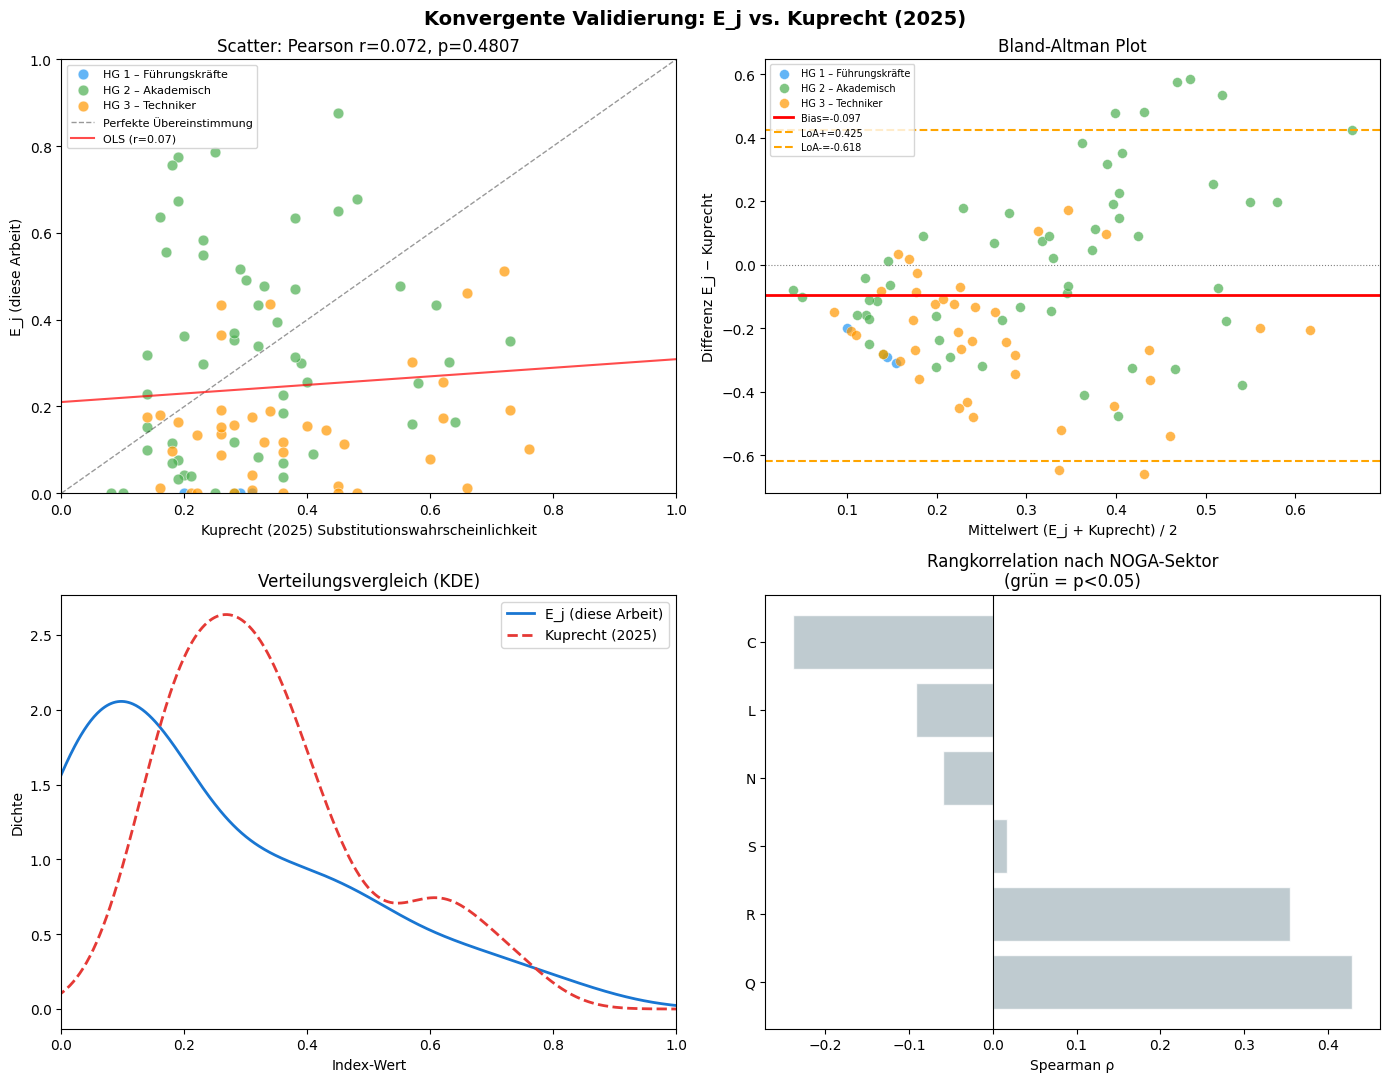

Abbildung gespeichert → output/figures/6_3_convergent_validation.png ✓


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Konvergente Validierung: E_j vs. Kuprecht (2025)", fontsize=14, fontweight="bold")

# ── 1. Scatter mit Regressionslinie ───────────────────────────────────────
ax = axes[0, 0]
for hg in sorted(val_data["main_group"].unique()):
    s = val_data[val_data["main_group"] == hg]
    ax.scatter(s["kuprecht_2025_score"], s["E_j"],
               label=hg_labels.get(int(hg), f"HG {hg}"), color=colors.get(int(hg), "gray"),
               alpha=0.7, s=60, edgecolors="white", linewidth=0.5)
# 45°-Linie (perfekte Übereinstimmung)
ax.plot([0,1], [0,1], "k--", linewidth=1, alpha=0.4, label="Perfekte Übereinstimmung")
# Regressionslinie via scipy (robuster als np.polyfit)
slope, intercept, *_ = stats.linregress(val_data["kuprecht_2025_score"], val_data["E_j"])
x_r = np.linspace(0, 1, 100)
ax.plot(x_r, intercept + slope * x_r, "r-", linewidth=1.5, alpha=0.7,
        label=f"OLS (r={r_pearson:.2f})")
ax.set_xlabel("Kuprecht (2025) Substitutionswahrscheinlichkeit")
ax.set_ylabel("E_j (diese Arbeit)")
ax.set_title(f"Scatter: Pearson r={r_pearson:.3f}, p={p_pearson:.4f}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# ── 2. Bland-Altman ───────────────────────────────────────────────────────
ax = axes[0, 1]
for hg in sorted(val_data["main_group"].unique()):
    mask = val_data["main_group"] == hg
    ax.scatter(mean_scores[mask], diff_scores[mask],
               color=colors.get(int(hg), "gray"), alpha=0.7, s=50,
               label=hg_labels.get(int(hg), f"HG {hg}"), edgecolors="white", linewidth=0.3)
ax.axhline(mean_diff,  color="red",    linewidth=2,   label=f"Bias={mean_diff:.3f}")
ax.axhline(loa_upper,  color="orange", linewidth=1.5, linestyle="--", label=f"LoA+={loa_upper:.3f}")
ax.axhline(loa_lower,  color="orange", linewidth=1.5, linestyle="--", label=f"LoA-={loa_lower:.3f}")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Mittelwert (E_j + Kuprecht) / 2")
ax.set_ylabel("Differenz E_j − Kuprecht")
ax.set_title("Bland-Altman Plot")
ax.legend(fontsize=7)

# ── 3. Verteilungsvergleich ───────────────────────────────────────────────
ax = axes[1, 0]
try:
    val_data["E_j"].plot.kde(ax=ax, color="#1976D2", linewidth=2, label="E_j (diese Arbeit)")
    val_data["kuprecht_2025_score"].plot.kde(ax=ax, color="#E53935", linewidth=2,
                                              label="Kuprecht (2025)", linestyle="--")
except Exception:
    ax.hist(val_data["E_j"], bins=15, alpha=0.5, color="#1976D2",
            density=True, label="E_j (diese Arbeit)")
    ax.hist(val_data["kuprecht_2025_score"], bins=15, alpha=0.5, color="#E53935",
            density=True, label="Kuprecht (2025)")
ax.set_xlim(0, 1)
ax.set_xlabel("Index-Wert")
ax.set_ylabel("Dichte")
ax.set_title("Verteilungsvergleich (KDE)")
ax.legend(fontsize=10)

# ── 4. Rangkorrelation nach NOGA-Sektor ───────────────────────────────────
ax = axes[1, 1]
sector_corr = []
for sector, grp in val_data.groupby("sector_noga"):
    if len(grp) >= 5:
        r, p = stats.spearmanr(grp["E_j"], grp["kuprecht_2025_score"])
        sector_corr.append({"sector": sector, "rho": r, "p": p, "n": len(grp)})

if sector_corr:
    sc_df = pd.DataFrame(sector_corr).sort_values("rho", ascending=False)
    bar_colors_sc = ["#4CAF50" if p < 0.05 else "#B0BEC5" for p in sc_df["p"]]
    ax.barh(sc_df["sector"], sc_df["rho"],
            color=bar_colors_sc, alpha=0.8, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Spearman ρ")
    ax.set_title("Rangkorrelation nach NOGA-Sektor\n(grün = p<0.05)")
else:
    ax.text(0.5, 0.5, "Zu wenig Berufe pro Sektor\nfür sektorale Analyse",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Sektorale Analyse (nicht möglich)")

plt.tight_layout()
plt.savefig(FIGURES / "6_3_convergent_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Abbildung gespeichert → output/figures/6_3_convergent_validation.png ✓")


## 6. Zusammenfassung und Beurteilung

In [8]:
# ── Validierungszusammenfassung ───────────────────────────────────────────
print("=" * 60)
print("VALIDIERUNGSZUSAMMENFASSUNG")
print("=" * 60)
print(f"  Gemeinsames Sample:        {len(val_data)} Berufe")
print(f"  Pearson r:                 {r_pearson:.3f} (p={p_pearson:.4f})")
print(f"  Spearman ρ:                {r_spearman:.3f} (p={p_spearman:.4f})")
print(f"  Bland-Altman Bias:         {mean_diff:.3f}")
print(f"  Limits of Agreement:       [{loa_lower:.3f}, {loa_upper:.3f}]")
print()
print("Interpretation:")
if abs(r_pearson) >= 0.50 and p_pearson < 0.05:
    print("  ✓ Konvergente Validität bestätigt: moderater bis starker,")
    print("    signifikanter Zusammenhang mit Kuprecht (2025).")
elif abs(r_pearson) >= 0.30 and p_pearson < 0.05:
    print("  ~ Partielle konvergente Validität: moderater Zusammenhang.")
    print("    Methodische Unterschiede erklären die Abweichungen.")
else:
    print("  ⚠ Schwache Korrelation – methodische Unterschiede dominieren.")
print()
print("Methodische Einordnung:")
print("  Kuprecht (2025): Skill-basiert, Frey & Osborne Logik, GPT-4-Kontext")
print("  Diese Arbeit:    LLM-spezifisch, μ_i-Kalibrierung, E_j-Formel")
print("  Erwartete Abweichung: plausibel, da LLM-Gewichtung kognitive")
print("  Tätigkeiten stärker gewichtet als generisches Fähigkeitsmodell.")

# Ergebnisse speichern
val_results = pd.DataFrame({
    "metric": ["pearson_r", "pearson_p", "spearman_rho", "spearman_p",
                "bland_altman_bias", "loa_upper", "loa_lower", "n_sample"],
    "value":  [r_pearson, p_pearson, r_spearman, p_spearman,
                mean_diff, loa_upper, loa_lower, len(val_data)]
}).round(4)
val_results.to_csv(FIGURES / "validation_results.csv", index=False)
print("\nGespeichert → data/processed/analysis_prep/validation_results.csv ✓")


VALIDIERUNGSZUSAMMENFASSUNG
  Gemeinsames Sample:        97 Berufe
  Pearson r:                 0.072 (p=0.4807)
  Spearman ρ:                0.123 (p=0.2297)
  Bland-Altman Bias:         -0.097
  Limits of Agreement:       [-0.618, 0.425]

Interpretation:
  ⚠ Schwache Korrelation – methodische Unterschiede dominieren.

Methodische Einordnung:
  Kuprecht (2025): Skill-basiert, Frey & Osborne Logik, GPT-4-Kontext
  Diese Arbeit:    LLM-spezifisch, μ_i-Kalibrierung, E_j-Formel
  Erwartete Abweichung: plausibel, da LLM-Gewichtung kognitive
  Tätigkeiten stärker gewichtet als generisches Fähigkeitsmodell.

Gespeichert → data/processed/analysis_prep/validation_results.csv ✓
